# Sample Corpus Train → Test Pipeline

Full **training and evaluation pipeline** driven by the SQL sample corpus:

```
SQLite DocumentStore
  → prepare classification / extraction splits
  → train TF-IDF + Random Forest (per application)
  → evaluate on held-out test split
  → run DICIE extraction eval on store-exported gold
  → summarize metrics
```

Applications:

- `medical_bills` — `hcfa` / `ub04` / `other`
- `salvage_claims` — `log` / `sales` / `other`

This uses only synthetic data (see [`docs/data_provenance.md`](../docs/data_provenance.md)).
Smoke-scale by default so it finishes quickly on CPU.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import logging
import sqlite3
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

CWD = Path.cwd().resolve()
REPO_ROOT = CWD if (CWD / "pyproject.toml").exists() else CWD.parent
assert (REPO_ROOT / "pyproject.toml").exists(), f"Could not find repo root from {CWD}"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.docie import DociePipeline
from src.docie.applications import list_applications, load_application
from src.docie.eval import evaluate_application
from src.docie.pipeline import run_file
from src.storage import DocumentStore
from src.storage.sample_generator import generate_claim_bundle, generate_corpus
from src.storage.schema import DDL, SCHEMA_VERSION
from src.storage.training import (
    fit_tfidf_random_forest,
    prepare_both_applications,
)
from src.storage.types import ClaimRecord, DocumentRecord, FieldRecord
from src.utils.config import Config
from src.utils.io import load_jsonl, read_json, write_json

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
cfg = Config.load()

DEMO = REPO_ROOT / "data" / "notebook_demo" / "sample_corpus"
DEMO.mkdir(parents=True, exist_ok=True)
DB_PATH = DEMO / "documents.db"
EXPORTS = DEMO / "exports"
EXPORTS.mkdir(parents=True, exist_ok=True)
PREPARED = DEMO / "prepared"
MODELS = DEMO / "models"
MODELS.mkdir(parents=True, exist_ok=True)

SEED = 42
print(f"repo:     {REPO_ROOT}")
print(f"demo db:  {DB_PATH}")
print(f"exports:  {EXPORTS}")
print(f"schema v: {SCHEMA_VERSION}")
print(f"apps:     {list_applications()}")

repo:     /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer
demo db:  /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/sample_corpus/documents.db
exports:  /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/sample_corpus/exports
schema v: 1
apps:     ['acord', 'medical_bills', 'salvage_claims']


In [2]:
SMOKE = True          # Fast RF + small corpus; set False for a larger run
MEDICAL_PER_TYPE = 10 if SMOKE else 30
SALVAGE_PER_TYPE = 10 if SMOKE else 30
BUNDLES = 2 if SMOKE else 4

if DB_PATH.exists():
    DB_PATH.unlink()
store = DocumentStore(DB_PATH)
corpus = generate_corpus(
    seed=SEED,
    medical_per_type=MEDICAL_PER_TYPE,
    salvage_per_type=SALVAGE_PER_TYPE,
    bundles_per_app=BUNDLES,
    include_canonical_fixtures=True,
)
store.bulk_upsert(corpus.documents, claims=corpus.claims)
store.add_provenance(
    stage="train_pipeline_seed",
    source="sample_corpus_train_test_pipeline",
    detail={"smoke": SMOKE, "documents": len(corpus.documents)},
)
display(store.summary())
pd.DataFrame(store.summary()["by_application_type"])

{'db_path': '/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/sample_corpus/documents.db',
 'schema_version': 1,
 'claims': 70,
 'documents': 78,
 'fields': 390,
 'by_application_type': [{'application': 'medical_bills',
   'document_type': 'hcfa',
   'count': 13},
  {'application': 'medical_bills', 'document_type': 'other', 'count': 13},
  {'application': 'medical_bills', 'document_type': 'ub04', 'count': 13},
  {'application': 'salvage_claims', 'document_type': 'log', 'count': 13},
  {'application': 'salvage_claims', 'document_type': 'other', 'count': 13},
  {'application': 'salvage_claims', 'document_type': 'sales', 'count': 13}]}

,application,document_type,count
0,medical_bills,hcfa,13
1,medical_bills,other,13
2,medical_bills,ub04,13
3,salvage_claims,log,13
4,salvage_claims,other,13
5,salvage_claims,sales,13


## 1. Prepare datasets from SQL (classification + extraction)

In [3]:
report = prepare_both_applications(store, PREPARED)
write_json(DEMO / "prepare_report.json", report)
print(json.dumps(report, indent=2)[:2000])

for app in ("medical_bills", "salvage_claims"):
    clf_summary = read_json(PREPARED / app / "classification" / "summary.json")
    ext_summary = read_json(PREPARED / app / "extraction" / "summary.json")
    print(app, "clf counts=", clf_summary["counts"], "ext all=", ext_summary["n_all"])

{
  "applications": {
    "medical_bills": {
      "classification": {
        "application": "medical_bills",
        "labels": [
          "hcfa",
          "ub04",
          "other"
        ],
        "counts": {
          "train": 26,
          "val": 5,
          "test": 8
        },
        "label_counts": {
          "hcfa": 13,
          "ub04": 13,
          "other": 13
        },
        "out_dir": "/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/sample_corpus/prepared/medical_bills/classification"
      },
      "extraction": {
        "application": "medical_bills",
        "extraction_fields": [
          "claim_id",
          "name",
          "dob",
          "patient_id",
          "address"
        ],
        "counts": {
          "train": 26,
          "val": 5,
          "test": 8
        },
        "n_all": 39,
        "out_dir": "/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/sample_corpus/prepared/medical_

### Peek prepared rows + split balance

In [4]:
rows = []
for app in ("medical_bills", "salvage_claims"):
    for split in ("train", "val", "test"):
        path = PREPARED / app / "classification" / f"{split}.jsonl"
        for r in load_jsonl(path):
            rows.append({"application": app, "split": split, "label": r["label"]})
bal = pd.DataFrame(rows)
display(pd.crosstab([bal.application, bal.split], bal.label, margins=True))

label                 hcfa  log  other  sales  ub04  All
application    split                                    
medical_bills  test      4    0      2      0     2    8
               train     8    0     10      0     8   26
               val       1    0      1      0     3    5
salvage_claims test      0    4      2      2     0    8
               train     0    8     10      8     0   26
               val       0    1      1      3     0    5
All                     13   13     26     13    13   78

## 2. Train TF-IDF + Random Forest classifiers from store splits

In [5]:
train_metrics = {}
for app in ("medical_bills", "salvage_claims"):
    prepared_dir = PREPARED / app / "classification"
    model_out = MODELS / f"{app}_tfidf_rf.joblib"
    metrics = fit_tfidf_random_forest(
        prepared_dir,
        model_out=model_out,
        random_state=SEED,
        smoke=SMOKE,
    )
    train_metrics[app] = metrics
    print(
        f"{app}: train={metrics['n_train']} val_acc={metrics.get('val_accuracy')} "
        f"test_acc={metrics.get('test_accuracy')} test_macro_f1={metrics.get('test_macro_f1')}"
    )

write_json(DEMO / "rf_train_metrics.json", train_metrics)
pd.DataFrame(
    [
        {
            "application": app,
            "n_train": m["n_train"],
            "n_test": m["n_test"],
            "val_accuracy": m.get("val_accuracy"),
            "test_accuracy": m.get("test_accuracy"),
            "test_macro_f1": m.get("test_macro_f1"),
        }
        for app, m in train_metrics.items()
    ]
)

medical_bills: train=26 val_acc=1.0 test_acc=1.0 test_macro_f1=1.0
salvage_claims: train=26 val_acc=1.0 test_acc=1.0 test_macro_f1=1.0


,application,n_train,n_test,val_accuracy,test_accuracy,test_macro_f1
0,medical_bills,26,8,1.0,1.0,1.0
1,salvage_claims,26,8,1.0,1.0,1.0


## 3. Test-set confusion matrices

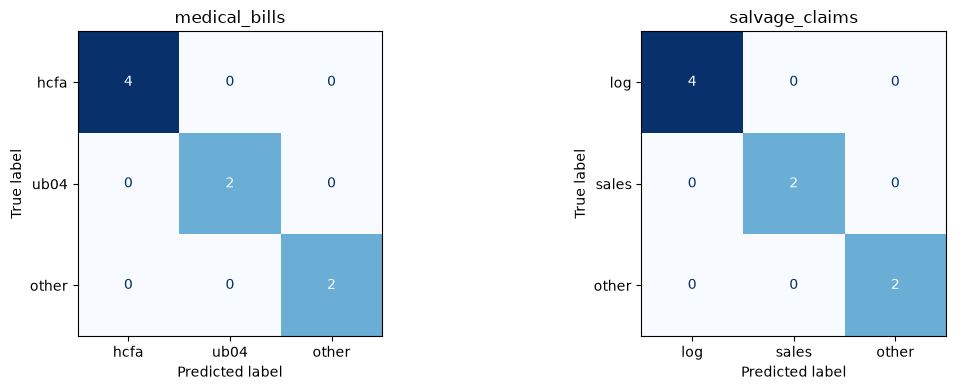

In [6]:
import joblib
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, app in zip(axes, ("medical_bills", "salvage_claims")):
    bundle = joblib.load(MODELS / f"{app}_tfidf_rf.joblib")
    pipe = bundle["pipeline"]
    labels = bundle["labels"]
    test_rows = load_jsonl(PREPARED / app / "classification" / "test.jsonl")
    y_true = [r["label"] for r in test_rows]
    y_pred = list(pipe.predict([r["text"] for r in test_rows])) if test_rows else []
    if not test_rows:
        ax.set_title(f"{app} (no test rows)")
        continue
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(app)
plt.tight_layout()
plt.show()

## 4. DICIE extraction eval on store-exported gold

In [7]:
docie_metrics = {}
for app in ("medical_bills", "salvage_claims"):
    gold = PREPARED / app / "extraction" / "docie_eval.jsonl"
    result = evaluate_application(
        app,
        eval_path=gold,
        cfg=cfg,
        run_ocr=False,
        limit=40 if SMOKE else None,
    )
    docie_metrics[app] = {
        "application": result["application"],
        "n": result["n"],
        "classification_accuracy": result["classification"]["accuracy"],
        "classification_macro_f1": result["classification"]["macro_f1"],
        "extraction_micro_f1": result["extraction"].get("micro_f1"),
        "extraction_macro_f1": result["extraction"].get("macro_f1"),
        "per_field": result["extraction"].get("per_field")
        or result["extraction"].get("fields"),
    }
    print(f"\n=== {app} ===")
    print(json.dumps(docie_metrics[app], indent=2)[:2000])

write_json(DEMO / "docie_eval_from_store.json", docie_metrics)
pd.DataFrame(
    [
        {
            "application": app,
            "n": m["n"],
            "clf_accuracy": m["classification_accuracy"],
            "clf_macro_f1": m["classification_macro_f1"],
            "ext_micro_f1": m["extraction_micro_f1"],
            "ext_macro_f1": m["extraction_macro_f1"],
        }
        for app, m in docie_metrics.items()
    ]
)

INFO src.docie.pipeline: Stage 1 processing med-hcfa-001 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify med-hcfa-001 → hcfa (0.975)
INFO src.docie.pipeline: Stage 3 extract med-hcfa-001 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing med-ub04-002 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify med-ub04-002 → ub04 (0.975)
INFO src.docie.pipeline: Stage 3 extract med-ub04-002 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing med-other-003 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify med-other-003 → other (0.805)
INFO src.docie.pipeline: Stage 3 extract med-other-003 — 1 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing med-hcfa-100 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify med-hcfa-100 → hcfa (0.975)
INFO src.docie.pipeline: Stage 3 extract med-hcfa-100 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing med-ub04


=== medical_bills ===
{
  "application": "medical_bills",
  "n": 39,
  "classification_accuracy": 1.0,
  "classification_macro_f1": 1.0,
  "extraction_micro_f1": 1.0,
  "extraction_macro_f1": 1.0,
  "per_field": {
    "name": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 39.0,
      "tp": 39.0,
      "fp": 0.0,
      "fn": 0.0
    },
    "dob": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 26.0,
      "tp": 26.0,
      "fp": 0.0,
      "fn": 0.0
    },
    "claim_id": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 26.0,
      "tp": 26.0,
      "fp": 0.0,
      "fn": 0.0
    },
    "patient_id": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 26.0,
      "tp": 26.0,
      "fp": 0.0,
      "fn": 0.0
    },
    "address": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 26.0,
      "tp": 26.0,
      "fp": 0.0,
      "fn":

INFO src.docie.pipeline: Stage 1 processing sal-log-102 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sal-log-102 → log (0.910)
INFO src.docie.pipeline: Stage 3 extract sal-log-102 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing sal-sales-102 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sal-sales-102 → sales (0.975)
INFO src.docie.pipeline: Stage 3 extract sal-sales-102 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing sal-other-102 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sal-other-102 → other (0.805)
INFO src.docie.pipeline: Stage 3 extract sal-other-102 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing sal-log-103 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sal-log-103 → log (0.910)
INFO src.docie.pipeline: Stage 3 extract sal-log-103 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing sal-sales-10


=== salvage_claims ===
{
  "application": "salvage_claims",
  "n": 39,
  "classification_accuracy": 1.0,
  "classification_macro_f1": 1.0,
  "extraction_micro_f1": 1.0,
  "extraction_macro_f1": 1.0,
  "per_field": {
    "claim_id": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 39.0,
      "tp": 39.0,
      "fp": 0.0,
      "fn": 0.0
    },
    "vin": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 38.0,
      "tp": 38.0,
      "fp": 0.0,
      "fn": 0.0
    },
    "make": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 38.0,
      "tp": 38.0,
      "fp": 0.0,
      "fn": 0.0
    },
    "model": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 38.0,
      "tp": 38.0,
      "fp": 0.0,
      "fn": 0.0
    },
    "year": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 38.0,
      "tp": 38.0,
      "fp": 0.0,
      "fn": 0.0
 

,application,n,clf_accuracy,clf_macro_f1,ext_micro_f1,ext_macro_f1
0,medical_bills,39,1.0,1.0,1.0,1.0
1,salvage_claims,39,1.0,1.0,1.0,1.0


## 5. Batch DICIE predictions written back as extracted fields

In [8]:
# Run salvage predictions and persist extracted fields into SQL (role=extracted)
salvage_export = EXPORTS / "train_pipeline_salvage_docie.jsonl"
store.export_jsonl(
    salvage_export, format="docie", application="salvage_claims", split="test"
)
pred_out = DEMO / "salvage_test_predictions.jsonl"
run_file(
    salvage_export,
    pred_out,
    application="salvage_claims",
    cfg=cfg,
    run_ocr=False,
)

n_updated = 0
for pred in load_jsonl(pred_out):
    rid = pred["record_id"]
    fields = pred.get("fields") or {}
    flat = {}
    for k, v in fields.items():
        if isinstance(v, list):
            flat[k] = v[0] if v else None
        else:
            flat[k] = v
    if not flat:
        continue
    conf = None
    if isinstance(pred.get("extraction"), dict):
        conf = pred["extraction"].get("confidence")
    store.set_fields(
        rid,
        {k: None if v is None else str(v) for k, v in flat.items()},
        role="extracted",
        confidence=conf,
    )
    n_updated += 1
print(f"wrote extracted fields for {n_updated} test documents")

cmp_sql = """
SELECT
  g.document_id,
  g.field_name,
  g.field_value AS ground_truth,
  e.field_value AS extracted
FROM document_fields g
LEFT JOIN document_fields e
  ON e.document_id = g.document_id
 AND e.field_name = g.field_name
 AND e.field_role = 'extracted'
WHERE g.field_role = 'ground_truth'
  AND g.document_id IN (
        SELECT document_id FROM documents
        WHERE split='test' AND application='salvage_claims'
      )
ORDER BY g.document_id, g.field_name
LIMIT 40
"""
with sqlite3.connect(DB_PATH) as conn:
    cmp = pd.read_sql_query(cmp_sql, conn)
cmp

INFO src.docie.pipeline: Stage 1 processing sal-log-001 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sal-log-001 → log (0.910)
INFO src.docie.pipeline: Stage 3 extract sal-log-001 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing sal-sales-002 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sal-sales-002 → sales (0.975)
INFO src.docie.pipeline: Stage 3 extract sal-sales-002 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing sal-other-003 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sal-other-003 → other (0.805)
INFO src.docie.pipeline: Stage 3 extract sal-other-003 — 1 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing sal-log-100 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sal-log-100 → log (0.910)
INFO src.docie.pipeline: Stage 3 extract sal-log-100 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing sal-sales-10

wrote extracted fields for 8 test documents


,document_id,field_name,ground_truth,extracted
0,sal-bundle00-log,claim_id,CLM-2022-536774,CLM-2022-536774
1,sal-bundle00-log,make,BMW,BMW
2,sal-bundle00-log,model,330i,330i
3,sal-bundle00-log,vin,WBA8E9G50JNU12345,WBA8E9G50JNU12345
4,sal-bundle00-log,year,2018,2018
5,sal-bundle01-log,claim_id,CLM-2023-165142,CLM-2023-165142
6,sal-bundle01-log,make,Toyota,Toyota
7,sal-bundle01-log,model,Corolla,Corolla
8,sal-bundle01-log,vin,2T1BURHE0JC123456,2T1BURHE0JC123456
9,sal-bundle01-log,year,2017,2017


## 6. Optional DistilBERT smoke train (transformers)

In [9]:
# Optional deep classifier smoke — skipped automatically if deps/data are insufficient.
RUN_TRANSFORMERS_SMOKE = False  # set True on machines with transformers + datasets installed

transformers_metrics = {}
if RUN_TRANSFORMERS_SMOKE:
    try:
        from src.classification.eval import evaluate as eval_clf
        from src.classification.train_classifier import train as train_clf

        for app in ("medical_bills", "salvage_claims"):
            prepared = PREPARED / app / "classification"
            out_dir = MODELS / f"{app}_distilbert_smoke"
            model_dir = train_clf(
                prepared_dir=prepared,
                cfg=cfg,
                output_dir=out_dir,
                smoke=True,
                wandb_settings=None,
            )
            metrics = eval_clf(model_dir=model_dir, prepared_dir=prepared, cfg=cfg)
            transformers_metrics[app] = {
                k: metrics[k]
                for k in metrics
                if k in ("accuracy", "macro_f1", "weighted_f1", "n")
            }
            print(app, transformers_metrics[app])
    except Exception as exc:
        print("Transformers smoke skipped/failed:", exc)
else:
    print("RUN_TRANSFORMERS_SMOKE=False — using TF-IDF RF metrics only")
write_json(DEMO / "transformers_smoke_metrics.json", transformers_metrics)

RUN_TRANSFORMERS_SMOKE=False — using TF-IDF RF metrics only


## 7. Pipeline scorecard

In [10]:
scorecard = []
for app, m in train_metrics.items():
    scorecard.append(
        {
            "application": app,
            "model": "tfidf_rf",
            "test_accuracy": m.get("test_accuracy"),
            "test_macro_f1": m.get("test_macro_f1"),
            "n_train": m["n_train"],
            "n_test": m["n_test"],
            "docie_clf_accuracy": docie_metrics[app]["classification_accuracy"],
            "docie_ext_micro_f1": docie_metrics[app]["extraction_micro_f1"],
        }
    )
score_df = pd.DataFrame(scorecard)
display(score_df)
write_json(
    DEMO / "pipeline_scorecard.json",
    {
        "rf": {
            app: {k: v for k, v in m.items() if k != "val_report" and k != "test_report"}
            for app, m in train_metrics.items()
        },
        "docie": docie_metrics,
        "db_path": str(DB_PATH),
        "prepared": str(PREPARED),
    },
)
print("artifacts under", DEMO)
for p in sorted(DEMO.rglob("*")):
    if p.is_file():
        print(" ", p.relative_to(DEMO))

,application,model,test_accuracy,test_macro_f1,n_train,n_test,docie_clf_accuracy,docie_ext_micro_f1
0,medical_bills,tfidf_rf,1.0,1.0,26,8,1.0,1.0
1,salvage_claims,tfidf_rf,1.0,1.0,26,8,1.0,1.0


artifacts under /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/sample_corpus
  docie_eval_from_store.json
  documents.db
  documents_roundtrip.db
  exports/sql_roundtrip_docie.jsonl
  exports/train_pipeline_salvage_docie.jsonl
  models/medical_bills_tfidf_rf.joblib
  models/medical_bills_tfidf_rf.metrics.json
  models/salvage_claims_tfidf_rf.joblib
  models/salvage_claims_tfidf_rf.metrics.json
  pipeline_scorecard.json
  prepare_report.json
  prepared/medical_bills/classification/all.jsonl
  prepared/medical_bills/classification/label2id.json
  prepared/medical_bills/classification/summary.json
  prepared/medical_bills/classification/test.jsonl
  prepared/medical_bills/classification/train.jsonl
  prepared/medical_bills/classification/val.jsonl
  prepared/medical_bills/extraction/docie_eval.jsonl
  prepared/medical_bills/extraction/summary.json
  prepared/medical_bills/extraction/test.jsonl
  prepared/medical_bills/extraction/train.jsonl
  prepared/medical

## Recap

1. **Seeded** a synthetic medical + salvage corpus into SQLite  
2. **Prepared** application-specific train/val/test JSONL from SQL splits  
3. **Trained / tested** TF-IDF + Random Forest classifiers per application  
4. **Evaluated** DICIE extraction against store-exported gold  
5. **Wrote** model extractions back into `document_fields` (`role=extracted`)

CLI equivalents:

```bash
python -m src.storage seed --seed 42
python -m src.storage export --format docie --application salvage_claims \
  --out data/sample_corpus/exports/salvage_docie.jsonl
python -m src.docie.eval --application salvage_claims \
  --eval-set data/notebook_demo/sample_corpus/prepared/salvage_claims/extraction/docie_eval.jsonl
```